# Import Libraries

In [12]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from collections import Counter


# Load Data and Preprocess

Total Cat images: 571
Total Dog images: 581
Total images in dataset: 1152
Training images: 920
Testing images: 232


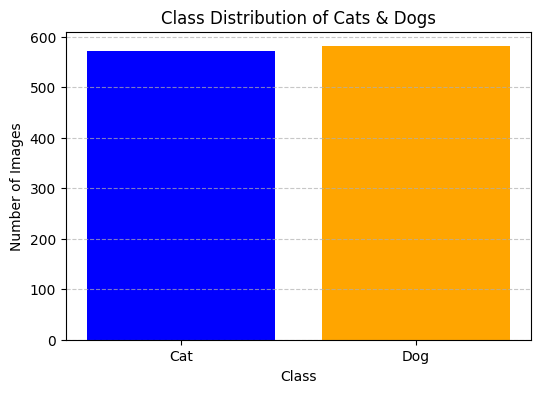


Train DataLoader Batch Distribution:
Batch 1: Cats = 32, Dogs = 32
Batch 2: Cats = 32, Dogs = 32
Batch 3: Cats = 32, Dogs = 32
Batch 4: Cats = 32, Dogs = 32
Batch 5: Cats = 32, Dogs = 32
Batch 6: Cats = 32, Dogs = 32
Batch 7: Cats = 32, Dogs = 32
Batch 8: Cats = 32, Dogs = 32
Batch 9: Cats = 32, Dogs = 32
Batch 10: Cats = 32, Dogs = 32


/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Batch 11: Cats = 32, Dogs = 32
Batch 12: Cats = 32, Dogs = 32
Batch 13: Cats = 32, Dogs = 32
Batch 14: Cats = 32, Dogs = 32

Test DataLoader Batch Distribution:
Batch 1: Cats = 32, Dogs = 32
Batch 2: Cats = 32, Dogs = 32
Batch 3: Cats = 32, Dogs = 32


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Ensure resizing to 224x224
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Set dataset path
data_dir = "/kaggle/input/cat-and-dog-classifier/data"  # Root directory

# Load the dataset using ImageFolder
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Get class labels
labels = np.array(dataset.targets)

# Function to create stratified splits
def stratified_split(labels, train_ratio=0.8):
    indices = np.arange(len(labels))
    train_indices = []
    test_indices = []

    # Split indices for each class
    for class_label in np.unique(labels):
        class_indices = indices[labels == class_label]
        np.random.shuffle(class_indices)
        split = int(train_ratio * len(class_indices))
        train_indices.extend(class_indices[:split])
        test_indices.extend(class_indices[split:])

    return train_indices, test_indices

# Create stratified splits
train_indices, test_indices = stratified_split(labels, train_ratio=0.8)

# Create Subsets for training and testing
train_dataset = Subset(dataset, train_indices)
test_dataset = Subset(dataset, test_indices)

# Custom Stratified Batch Sampler
class StratifiedBatchSampler:
    def __init__(self, labels, batch_size, shuffle=True):
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle

        # Get indices for each class
        self.class_indices = {class_label: np.where(labels == class_label)[0] for class_label in np.unique(labels)}

        # Calculate the number of batches
        self.num_batches = len(labels) // batch_size

    def __iter__(self):
        # Shuffle indices for each class
        if self.shuffle:
            for class_label in self.class_indices:
                np.random.shuffle(self.class_indices[class_label])

        # Create batches
        for batch_idx in range(self.num_batches):
            batch_indices = []
            for class_label in self.class_indices:
                start = batch_idx * (self.batch_size // len(self.class_indices))
                end = (batch_idx + 1) * (self.batch_size // len(self.class_indices))
                batch_indices.extend(self.class_indices[class_label][start:end])
            yield batch_indices

    def __len__(self):
        return self.num_batches

# Create stratified batch samplers
train_sampler = StratifiedBatchSampler(labels[train_indices], batch_size=64, shuffle=True)
test_sampler = StratifiedBatchSampler(labels[test_indices], batch_size=64, shuffle=False)

# Create DataLoader with stratified batch samplers
train_loader = DataLoader(train_dataset, batch_sampler=train_sampler)
test_loader = DataLoader(test_dataset, batch_sampler=test_sampler)

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Print class distribution
class_counts = Counter(labels)
for class_name, count in zip(dataset.classes, class_counts.values()):
    print(f"Total {class_name} images: {count}")

print(f"Total images in dataset: {len(dataset)}")
print(f"Training images: {len(train_dataset)}")
print(f"Testing images: {len(test_dataset)}")

# Create bar chart
plt.figure(figsize=(6, 4))
plt.bar(dataset.classes, class_counts.values(), color=['blue', 'orange'])
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Cats & Dogs")
plt.xticks(rotation=0)  # Keep labels horizontal
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Function to display class distribution per batch
def display_batch_distribution(data_loader, dataset_type="Train"):
    print(f"\n{dataset_type} DataLoader Batch Distribution:")
    for batch_idx, (images, labels) in enumerate(data_loader):
        label_counts = Counter(labels.numpy())  # Count occurrences of each class in the batch
        num_cats = label_counts.get(0, 0)  # Class 0 = Cats
        num_dogs = label_counts.get(1, 0)  # Class 1 = Dogs
        print(f"Batch {batch_idx + 1}: Cats = {num_cats}, Dogs = {num_dogs}")

# Display distribution for training and testing batches
display_batch_distribution(train_loader, "Train")
display_batch_distribution(test_loader, "Test")

# Plot Train and Test Images

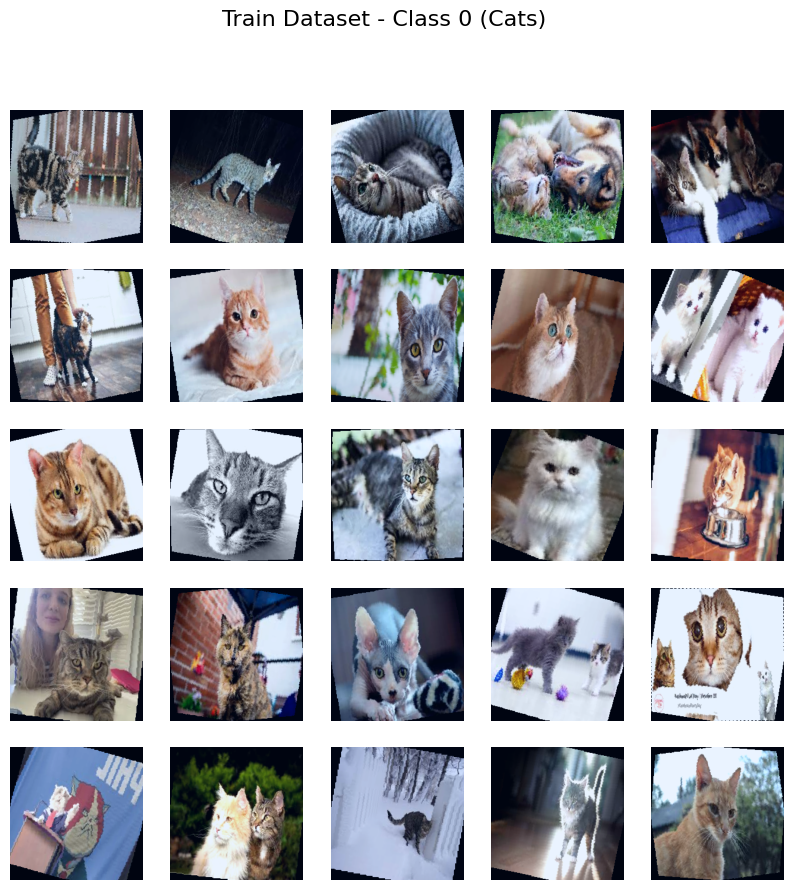

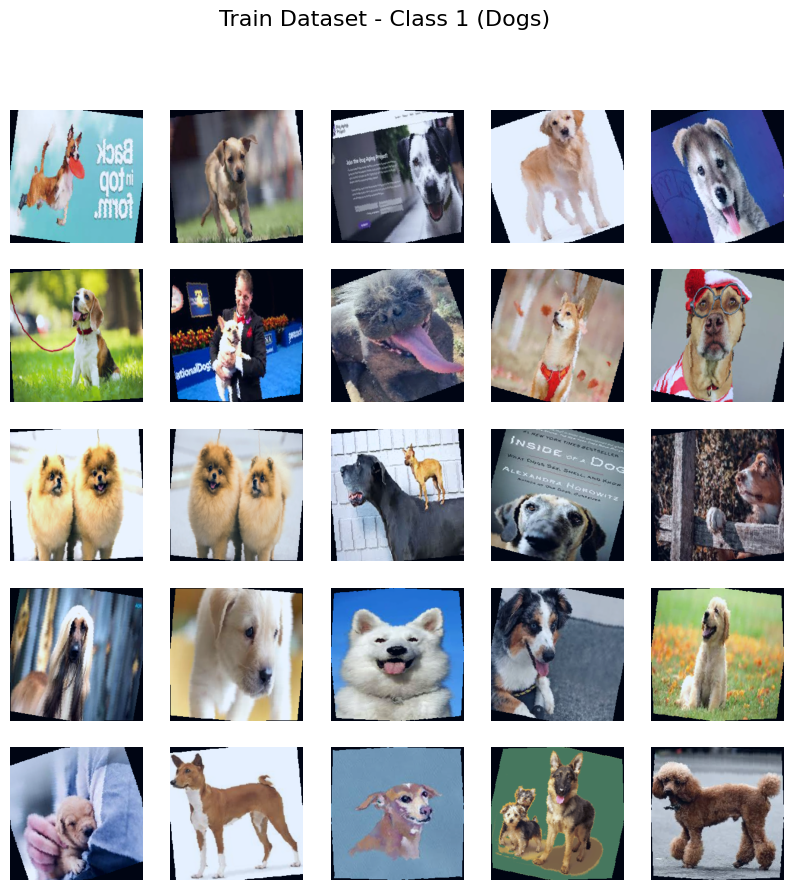

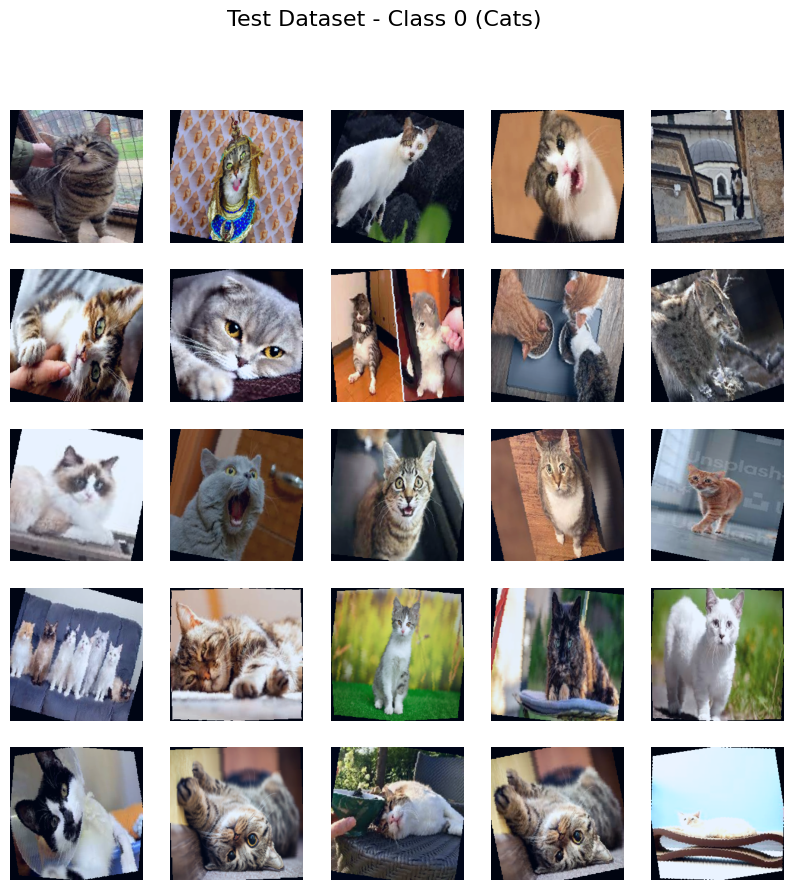

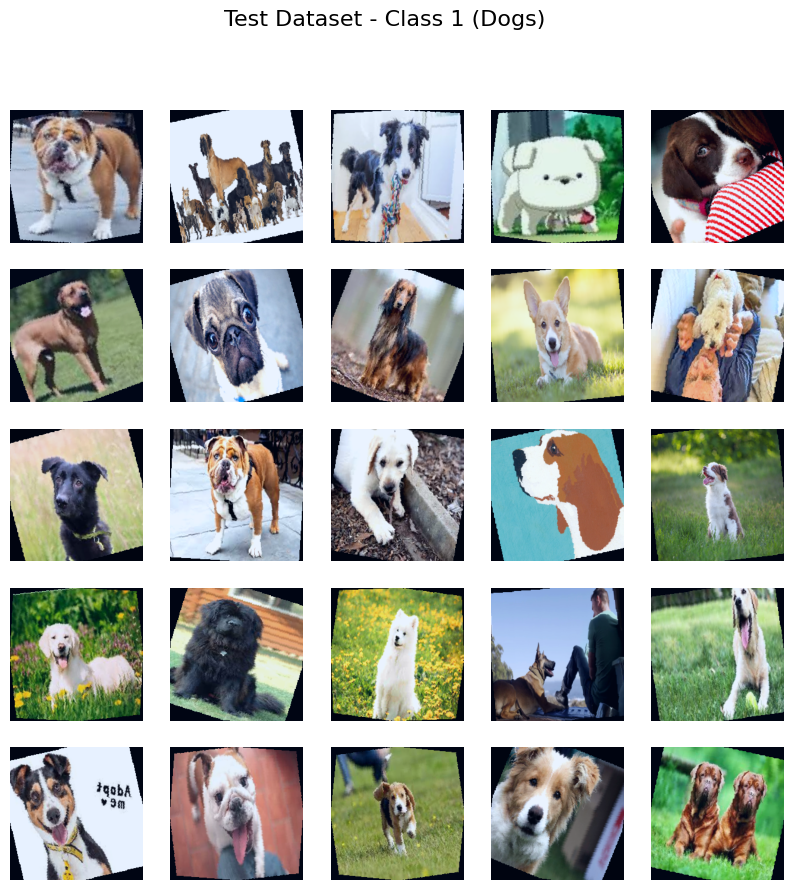

In [ ]:
# Function to plot 5x5 images for each class from train and test datasets
def plot_class_images(data_loader, class_label, dataset_type="Train", num_images=25):
    images_collected = []

    # Collect images of the given class
    for images, labels in data_loader:
        for img, label in zip(images, labels):
            if label.item() == class_label:
                images_collected.append(img)
            if len(images_collected) >= num_images:
                break
        if len(images_collected) >= num_images:
            break

    # Convert to numpy for visualization
    images_collected = [img.permute(1, 2, 0).cpu().numpy() for img in images_collected]

    # Plot the images
    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    fig.suptitle(f"{dataset_type} Dataset - Class {class_label} ({'Cats' if class_label == 0 else 'Dogs'})", fontsize=16)

    for ax, img in zip(axes.flatten(), images_collected):
        img = (img - img.min()) / (img.max() - img.min())  # Normalize for display
        ax.imshow(img)
        ax.axis("off")

    plt.show()

# Plot 5x5 images for Cats and Dogs from both train and test datasets
plot_class_images(train_loader, class_label=0, dataset_type="Train")  # Cats in Train
plot_class_images(train_loader, class_label=1, dataset_type="Train")  # Dogs in Train
plot_class_images(test_loader, class_label=0, dataset_type="Test")    # Cats in Test
plot_class_images(test_loader, class_label=1, dataset_type="Test")    # Dogs in Test


# Patches for ViT

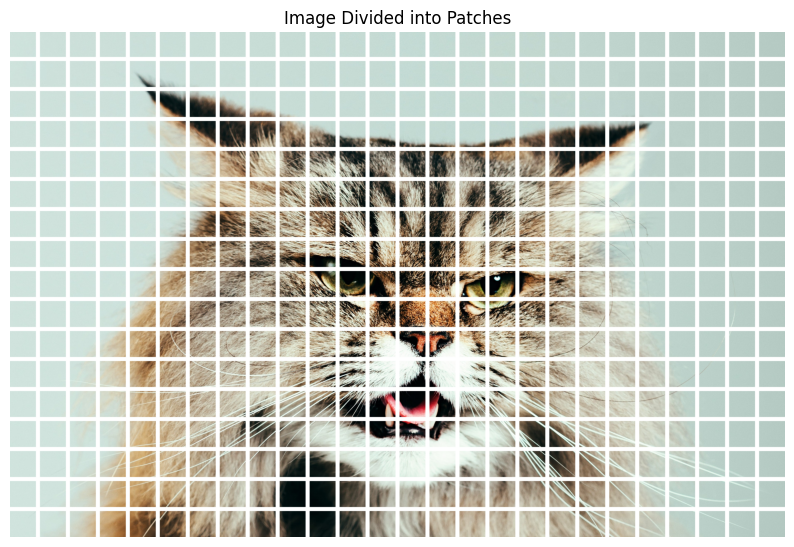

In [ ]:
def show_image_patches(image_path, patch_size=64, spacing=20):  # Increased patch size
    # Read image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

    img_h, img_w, _ = image.shape
    num_patches_x = img_w // patch_size
    num_patches_y = img_h // patch_size

    # Extract patches
    patches = []
    for i in range(num_patches_y):
        for j in range(num_patches_x):
            y_start = i * patch_size
            y_end = y_start + patch_size
            x_start = j * patch_size
            x_end = x_start + patch_size
            patch = image[y_start:y_end, x_start:x_end]
            patches.append(patch)

    # Create a new image to display patches as separate boxes
    grid_rows = num_patches_y
    grid_cols = num_patches_x
    # Calculate the size of the new image with spacing
    new_img_h = grid_rows * patch_size + (grid_rows - 1) * spacing
    new_img_w = grid_cols * patch_size + (grid_cols - 1) * spacing
    new_img = np.ones((new_img_h, new_img_w, 3), dtype=np.uint8) * 255  # White background

    # Place patches in the new image with spacing
    for i in range(grid_rows):
        for j in range(grid_cols):
            y_start = i * (patch_size + spacing)
            y_end = y_start + patch_size
            x_start = j * (patch_size + spacing)
            x_end = x_start + patch_size
            new_img[y_start:y_end, x_start:x_end] = patches[i * grid_cols + j]

    # Show the patched image
    plt.figure(figsize=(10, 10))  # Increased figure size for better visualization
    plt.imshow(new_img)
    plt.axis('off')
    plt.title("Image Divided into Patches")
    plt.show()

# Example usage with larger patches
show_image_patches("/kaggle/input/cat-and-dog-classifier/data/Cat/1521-WIRED-Cat.jpeg", patch_size=128, spacing=20)

# ViT Architecture

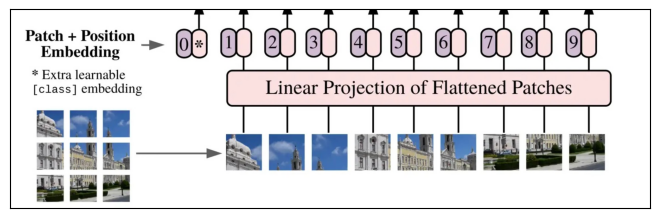

In [8]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2

        self.proj = nn.Conv2d(
            in_channels, embed_dim, kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)  # (B, embed_dim, H, W)
        x = x.flatten(2)  # (B, embed_dim, n_patches)
        x = x.transpose(1, 2)  # (B, n_patches, embed_dim)
        return x



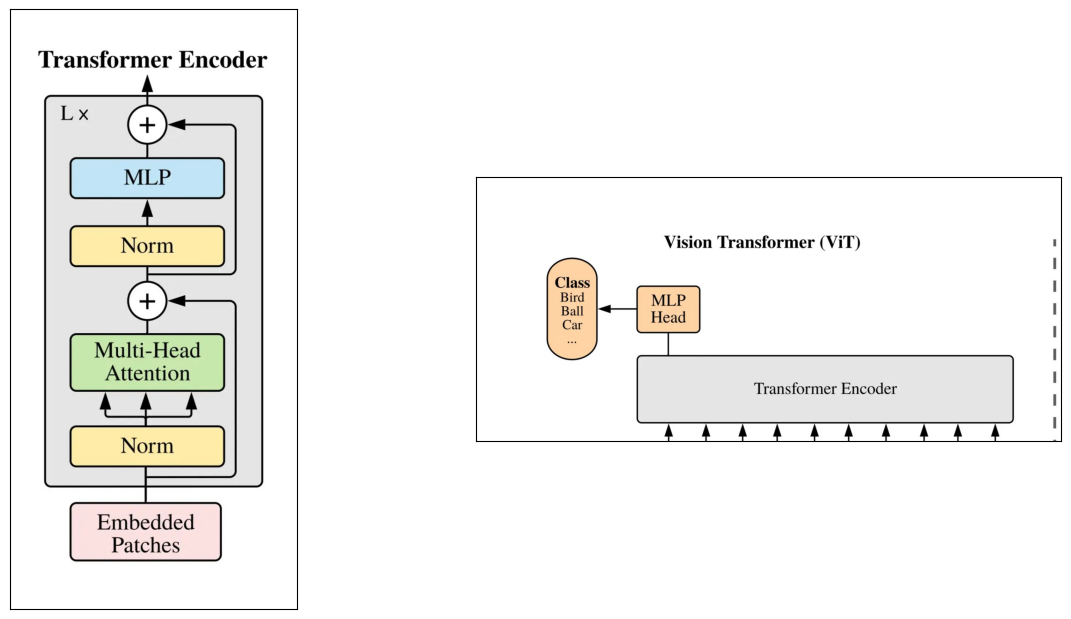

In [11]:

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=768, num_heads=12, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)

        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, N, C = x.shape

        q = self.query(x).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.key(x).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.value(x).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn_probs = F.softmax(attn_scores, dim=-1)
        attn_probs = self.dropout(attn_probs)

        x = (attn_probs @ v).transpose(1, 2).reshape(B, N, C)
        x = self.out(x)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=768, num_heads=12, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * mlp_ratio),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * mlp_ratio, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, num_classes=1000, embed_dim=768, depth=12, num_heads=12, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.n_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)
        cls_token_final = x[:, 0]
        x = self.head(cls_token_final)
        return x



# Model Setup

In [ ]:
# Initialize model, loss, and optimizer
device = 'cuda' if torch.cuda.is_available() else 'cpu'
vit_model = VisionTransformer(num_classes=2).to(device)  # 2 classes for dog vs. cat
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vit_model.parameters(), lr=3e-4, weight_decay=1e-4)  # Add weight decay for regularization

# Learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3, verbose=True)

# Early stopping
early_stopping_patience = 5
best_val_accuracy = 0
epochs_without_improvement = 0

# Mixed precision training
scaler = torch.cuda.amp.GradScaler()

# Train, Evaluate, Ploting Functions

In [ ]:

# Training function with improvements
def train(model, train_loader, criterion, optimizer, device, epochs=10):
    global best_val_accuracy, epochs_without_improvement
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        # Wrap train_loader with tqdm
        train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for images, labels in train_loader_tqdm:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            # Mixed precision training
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Update tqdm description with current loss and accuracy
            train_loader_tqdm.set_postfix(loss=running_loss / (total / labels.size(0)), accuracy=100 * correct / total)

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}, Accuracy: {train_accuracy:.2f}%")

        # Evaluate on validation set (for scheduler)
        val_accuracy = evaluate(model, test_loader, device, return_predictions=False)

        # Learning rate scheduling
        scheduler.step(val_accuracy)

        # Early stopping
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            epochs_without_improvement = 0
            # Save the best model
            torch.save(model.state_dict(), 'best_vit_model.pth')
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

def evaluate(model, test_loader, device, return_predictions=False):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    # Wrap test_loader with tqdm
    test_loader_tqdm = tqdm(test_loader, desc="Evaluating", leave=False)
    with torch.no_grad():
        for images, labels in test_loader_tqdm:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Update tqdm description with current accuracy
            test_loader_tqdm.set_postfix(accuracy=100 * correct / total)

    val_accuracy = 100 * correct / total
    print(f"Validation Accuracy: {val_accuracy:.2f}%")

    if return_predictions:
        return all_preds, all_labels  # Return predictions and true labels
    else:
        return val_accuracy  # Return validation accuracy for scheduler

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()

def plot_predictions(model, test_loader, class_names, device, num_images=20):
    model.eval()
    images_shown = 0
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))  # 4 rows, 5 columns
    axes = axes.ravel()

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)

            for i in range(len(images)):
                if images_shown >= num_images:
                    break
                img = images[i].cpu().permute(1, 2, 0).numpy()
                img = (img - img.min()) / (img.max() - img.min())  # Normalize for display

                axes[images_shown].imshow(img)
                axes[images_shown].set_title(f"Pred: {class_names[predicted[i]]}\nActual: {class_names[labels[i]]}")
                axes[images_shown].axis("off")
                images_shown += 1

            if images_shown >= num_images:
                break

    plt.tight_layout()
    plt.show()



# Training and Evaluating ViT

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
<ipython-input-17-76e1fd7178a9>:136: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1/30:   0%|          | 0/14 [00:00<?, ?it/s]<ipython-input-17-76e1fd7178a9>:155: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/30, Loss: 1.8209, Accuracy: 49.33%


Validation Accuracy: 52.08%


Epoch 2/30, Loss: 0.6998, Accuracy: 50.89%


Validation Accuracy: 50.00%


...

Validation Accuracy: 59.90%


Epoch 16/30, Loss: 0.6580, Accuracy: 62.28%


<ipython-input-17-76e1fd7178a9>:268: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vit_model.load_state_dict(torch.load('best_vit_model.pth'))


Validation Accuracy: 63.02%
Early stopping at epoch 16


Validation Accuracy: 71.35%


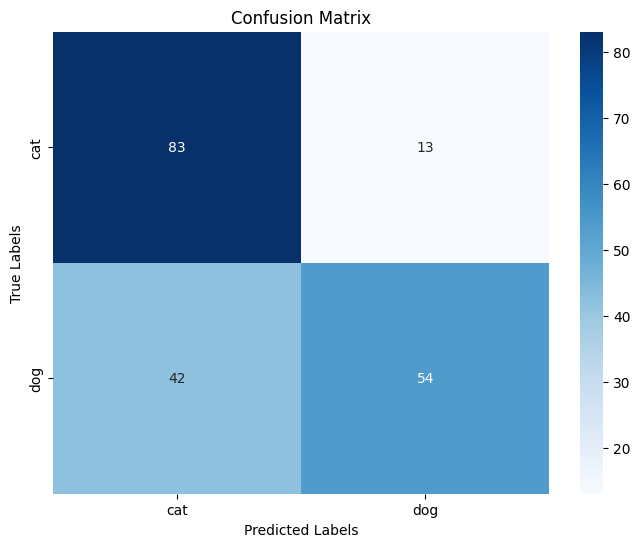

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


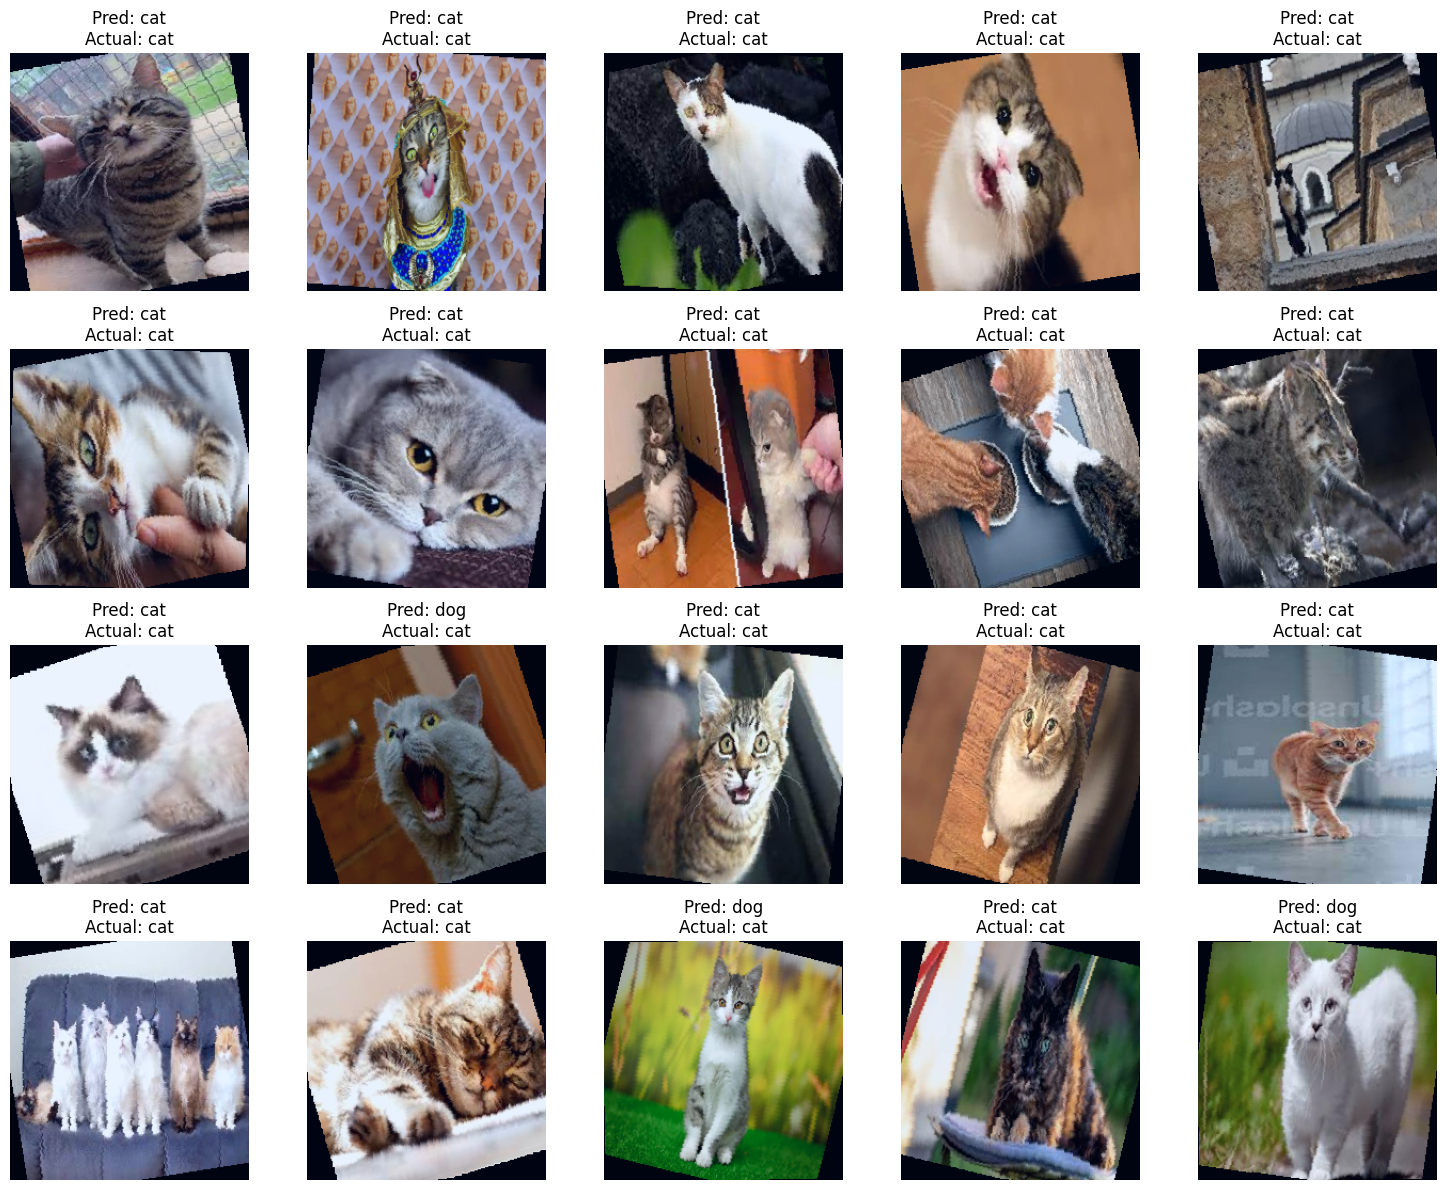

In [ ]:
# Train the model
train(vit_model, train_loader, criterion, optimizer, device, epochs=30)

# Load the best model
vit_model.load_state_dict(torch.load('best_vit_model.pth'))

# Evaluate the model (for predictions)
y_pred, y_true = evaluate(vit_model, test_loader, device, return_predictions=True)

# Plot confusion matrix and predictions
class_names = ['cat', 'dog']  # Update with your dataset's class names
plot_confusion_matrix(y_true, y_pred, class_names)
plot_predictions(vit_model, test_loader, class_names, device)